# NFL Offensive Tendencies Clustering: 2025

Do NFL teams with similar offensive playcalling win at similar rates? Is it possible to identify strategies that lead to more wins without using subjective analysis?

The terms "run-heavy", "pass-first", or "spread offense" are often used in NFL discourse to describe a team's offense. In this project, these categories and more will be build from the ground up using NFL play-by-play and formation data from the 2025 season to determine two things:

1. Play Archetype Clustering: every single offensive play from the 2025 season will be assigned a group based on context and offensive decision. This will create distinct play archetypes.

2. Team Offensive Philisophy Clustering: each team will be represented as a distribution of these play archetypes, and then clustered between each other a second time by similar mixes of play archetypes called over the season.

All data is sourced from nflreadpy.

In [129]:
!pip install nflreadpy
!pip install appdirs
!pip install matplotlib

In [130]:
import nflreadpy as nfl
import pandas as pd
import os
import matplotlib.pyplot as plt
import numpy as np
import re
import joblib
from sklearn.cluster import KMeans


In [131]:
pbp_2025 = nfl.load_pbp([2025])
schedules_2025 = nfl.load_schedules([2025])
participation_2025 = nfl.load_participation([2025])
pbp_2025 = pbp_2025.to_pandas()
schedules_2025 = schedules_2025.to_pandas()
participation_2025 = participation_2025.to_pandas()

In [132]:
important_cols = ["game_id",
                  "game_type",
                  "home_coach",
                  "away_coach",
                  "home_team",
                  "away_team",
                  "location",
                  "result"]

schedules_2025 = schedules_2025[important_cols]

In [133]:
schedules_2025 = schedules_2025[schedules_2025["game_type"] == "REG"]

In [134]:
home_rows = schedules_2025.copy()
home_rows["team"] = home_rows["home_team"]
home_rows["opponent"] = home_rows["away_team"]
home_rows["coach"] = home_rows["home_coach"]
home_rows["is_home"] = True

away_rows = schedules_2025.copy()
away_rows["team"] = away_rows["away_team"]
away_rows["opponent"] = away_rows["home_team"]
away_rows["coach"] = away_rows["away_coach"]
away_rows["is_home"] = False

schedules_2025 = pd.concat([home_rows, away_rows])
schedules_2025 = schedules_2025.drop(columns = ["game_type",
                                                "home_coach",
                                                "away_coach",
                                                "home_team",
                                                "away_team"])
games_2025 = schedules_2025

In [135]:
games_2025["point_diff"] = np.where(
    games_2025["is_home"],
    games_2025["result"],
    -games_2025["result"]
)

games_2025["is_win"] = np.where(schedules_2025["point_diff"] > 0,
                                1,
                                0
)

season_stats = (
    games_2025.groupby(["team", "coach"], as_index = False)
.agg(
    wins = ("is_win", "sum"),
    differential = ("point_diff", "sum")
  )
)

season_stats = season_stats.sort_values(by = ["wins", "differential"], ascending = False).reset_index(drop = True)

# Feature Selection and Engineering

In this exercise, features were seperated into "context" and "decision" features.

Context refers to the situation that an offensive coordinator is facing; the score, field position, defensive formation.

Decision refers to the perceivable actions that the offensive coordinator took in reaction to said context.

By grouping data into these two categories, we can determine, for each play, how coaches react differently to different contexts.

In [136]:
raw_context_cols = [
    "game_id", "posteam", "defteam", "yardline_100", "half_seconds_remaining", "game_seconds_remaining", "game_half",
    "drive", "down", "goal_to_go", "ydstogo", "posteam_timeouts_remaining", "defteam_timeouts_remaining",
    "posteam_score", "defteam_score", "fg_prob", "td_prob", "extra_point_prob", "two_point_conversion_prob", "wp",
    "qtr", "season_type", "series", "ep", "xpass", "play_id"
]

raw_context_df = pbp_2025[raw_context_cols].copy()

In [137]:
from collections import Counter

def count_positions(positions_string):
  position_list = positions_string.strip().upper().split(";")
  return dict(Counter(position_list))

def get_count(pos_dict, position_key):
  if isinstance(pos_dict, dict):
    return pos_dict.get(position_key, 0)
  else:
    return 0

defensive_context_cols = [
    "nflverse_game_id", "play_id", "possession_team", "defense_positions", "defenders_in_box", "number_of_pass_rushers",
    "defense_coverage_type"
]

defensive_context_df = participation_2025[defensive_context_cols].copy()
defensive_context_df["position_counts"] = defensive_context_df["defense_positions"].apply(count_positions)
defensive_context_df = defensive_context_df.rename(columns = {"nflverse_game_id": "game_id"})

position_columns_df = pd.DataFrame.from_records(defensive_context_df["position_counts"].fillna({}))
position_columns_df = position_columns_df.fillna(0).astype(int)
position_columns_df.columns = [f"n_{c.lower()}" for c in position_columns_df.columns]

defensive_context_df = pd.concat([defensive_context_df, position_columns_df], axis=1)

defensive_context_df = defensive_context_df.drop(columns=["defense_positions", "position_counts"])

In [138]:
final_context_df = raw_context_df.merge(
    defensive_context_df,
    on = ["game_id", "play_id"],
    how = "left"
)

In [139]:
offensive_decision_cols = [
    "nflverse_game_id", "play_id", "possession_team", "offense_positions", "offense_formation"
]

offensive_decision_df = participation_2025[offensive_decision_cols].copy()
offensive_decision_df = offensive_decision_df.rename(columns = {"nflverse_game_id": "game_id"})

offensive_decision_df["position_counts"] = offensive_decision_df["offense_positions"].apply(count_positions)

position_columns_df = pd.DataFrame.from_records(offensive_decision_df["position_counts"].fillna({}))
position_columns_df = position_columns_df.fillna(0).astype(int)
position_columns_df.columns = [f"n_off_{c.lower()}" for c in position_columns_df.columns]

offensive_decision_df = pd.concat([offensive_decision_df, position_columns_df], axis=1)

offensive_decision_df = offensive_decision_df.drop(columns=["offense_positions", "position_counts"])

In [140]:
offensive_pbp_cols = [
    "game_id", "play_id", "posteam", "play_type", "shotgun", "no_huddle", "qb_dropback", "qb_kneel", "qb_spike",
    "qb_scramble", "pass_length", "pass_location", "air_yards", "yards_after_catch", "run_location", "run_gap",
    "timeout", "timeout_team", "pass_oe", "special_teams_play", "two_point_attempt", "extra_point_attempt",
    "cp"
]

offensive_pbp_df = pbp_2025[offensive_pbp_cols].copy()

In [141]:
final_decision_df = offensive_pbp_df.merge(
    offensive_decision_df,
    on = ["game_id", "play_id"],
    how = "left"
)

In [143]:
duplicate_columns = [column for column in final_decision_df if column in final_context_df and column not in ["game_id", "play_id"]]
clean_decision_df = final_decision_df.drop(columns=duplicate_columns)

master_df = final_context_df.merge(
    clean_decision_df,
    on = ["game_id", "play_id"],
    how = "inner"
)

master_df = master_df[
    (master_df["special_teams_play"] == 0) &
    (master_df["play_type"].isin(["pass", "run"])) &
    (master_df["qb_kneel"] == 0) &
    (master_df["qb_spike"] == 0) &
    (master_df["posteam"].notna()) &
    (master_df["down"].notna()) &

    (master_df["season_type"] == "REG")
]

categorical_fills = {
    "pass_location": "UNKNOWN",
    "pass_length": "UNKNOWN",
    "run_location": "UNKNOWN",
    "run_gap": "UNKNOWN",
    "offense_formation": "UNKNOWN",
    "defense_coverage_type": "UNKNOWN",
    "cp": "UNKNOWN"
}
master_df = master_df.fillna(value=categorical_fills)

master_df["pass_oe"] = master_df["pass_oe"].fillna(0)
master_df["air_yards"] = master_df["air_yards"].fillna(0)
master_df["yards_after_catch"] = master_df["yards_after_catch"].fillna(0)

print(f"Number of plays for clustering = {len(master_df)}")

Number of plays for clustering = 32814


In [144]:
from sklearn.preprocessing import StandardScaler

id_cols = ["game_id", "play_id", "posteam", "defteam", "play_type"]
df_ids = master_df[id_cols].copy()

def_pos_cols = [c for c in master_df.columns if c.startswith("n_") and not c.startswith("n_off_")]
off_pos_cols = [c for c in master_df.columns if c.startswith("n_off_")]

master_df["posteam_score"] = pd.to_numeric(master_df["posteam_score"], errors='coerce').fillna(0)
master_df["defteam_score"] = pd.to_numeric(master_df["defteam_score"], errors='coerce').fillna(0)
master_df["score_differential"] = master_df["posteam_score"] - master_df["defteam_score"]

context_continuous = [
    "yardline_100", "half_seconds_remaining", "game_seconds_remaining", "ydstogo", "goal_to_go",
    "score_differential", "fg_prob", "td_prob", "wp", "ep", "xpass"
]

context_categorical = [
    "game_half", "down","qtr", "defense_coverage_type", "drive", "series", "posteam_timeouts_remaining",
    "defteam_timeouts_remaining", "defenders_in_box", "number_of_pass_rushers"
]+ def_pos_cols

decision_categorical = [
    "play_type", "shotgun", "no_huddle", "qb_dropback", "qb_scramble", "pass_length",
    "pass_location", "run_location", "run_gap", "timeout", "offense_formation"
]+ off_pos_cols

scaler = StandardScaler()
X_scaled = scaler.fit_transform(master_df[context_continuous].fillna(0))
df_cont = pd.DataFrame(X_scaled, columns = context_continuous, index = master_df.index)

all_categorical = context_categorical + decision_categorical
df_cat = pd.get_dummies(master_df[all_categorical].astype(str), dtype = int)

X_final = pd.concat([df_cont, df_cat], axis = 1)

# Determining optimal number of clusters

The following figure is a commonly used technique to determine the optimal number of clusters. Standard is to choose the number of clusters, k, which displays diminishing returns to reduction in within cluster variance in all k after.

For this exercise, the elbow plot did not give as clear an answer as ideal, however a small flattening can be seen after k = 10 has passed. For this reason, 10 clusters was chosen as the number of play archetypes that will be determined.

In [145]:
inertia = []
k_range = range(4, 16)

for k in k_range:
  kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
  kmeans.fit(X_final)
  inertia.append(kmeans.inertia_)

plt.figure(figsize = (10, 6))
plt.plot(k_range, inertia, marker = "o", linestyle = "-", color = "blue")
plt.xlabel("Number of Play Archetypes", fontsize = 12)
plt.ylabel("Inertia (total within cluster variance)", fontsize = 12)
plt.title("Elbow method (Play Archetyping)")
plt.xticks(k_range)
plt.grid(True, linestyle = "--", alpha = 0.6)
plt.show()

KeyboardInterrupt: 

In [146]:
optimal_k = 10

final_kmeans = KMeans(n_clusters = optimal_k, random_state = 42, n_init = 10)
master_df["play_archetype"] = final_kmeans.fit_predict(X_final)

preview_cols = ["posteam", "down", "ydstogo", "score_differential", "play_type", "shotgun", "offense_formation"]

# Defining Play Archetype

Now that we've determined the optimal number of play archetypes, it will be useful to clearly define what each play archetype means.

Play Archetype refers to a group that each offensive play on the field can be put in to. Examples of play archetypes that are frequently heard in NFL discourse are Vertical / Air Raids, Slants, Screens, etc.

The below figure displays the percentage of a team's playbook which was shown to be apart of a certain play archetype over the 2025 season.

Based on the goal of this exercise, it is not useful to label/name the play archetypes we've clustered, since the goal is to determine groups of teams, not groups of plays.

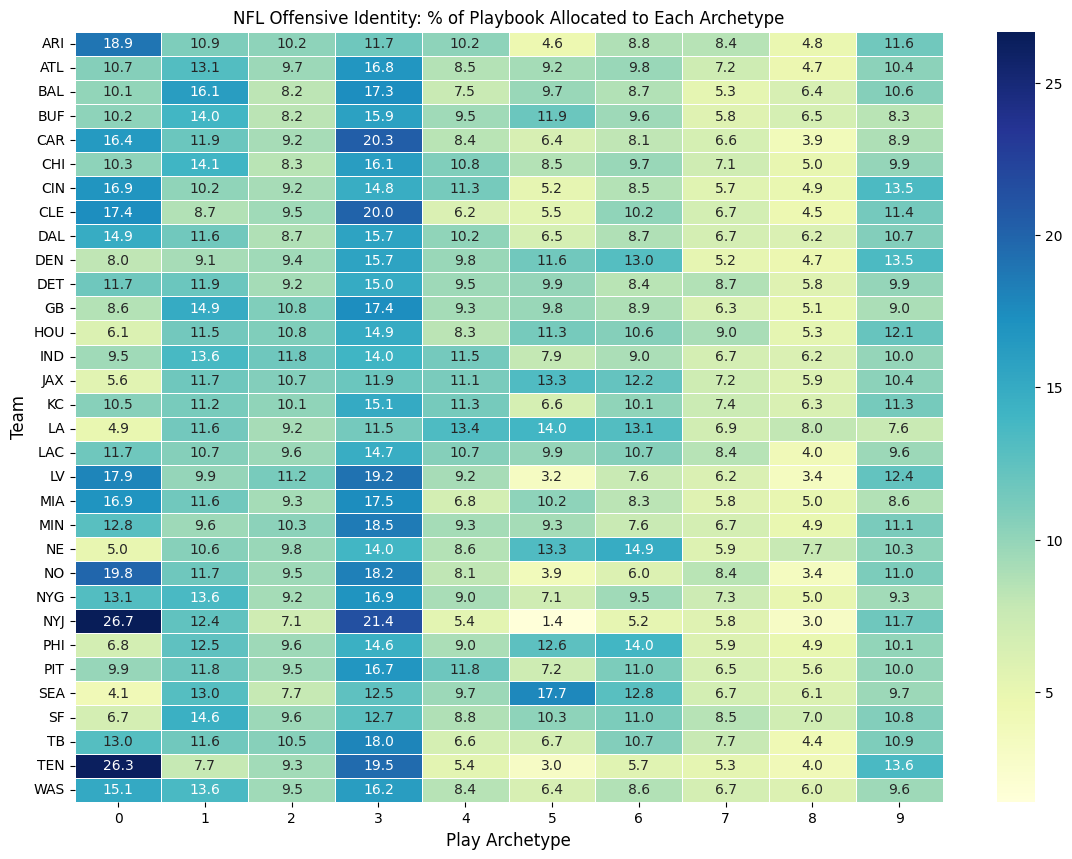

In [147]:
import seaborn as sns

coach_profiles = pd.crosstab(master_df["posteam"], master_df["play_archetype"], normalize = "index") * 100

plt.figure(figsize = (14, 10))
sns.heatmap(coach_profiles, annot = True, fmt = ".1f", cmap = "YlGnBu", linewidths = .5)
plt.title("NFL Offensive Identity: % of Playbook Allocated to Each Archetype")

plt.xlabel("Play Archetype", fontsize = 12)
plt.ylabel("Team", fontsize = 12)
plt.show()

# Team Clustering

Now that we've determined what teams use which types of plays more often, we perform clustering a second time to determine which of these teams are most similar to each other.

K = 9 was used in this case because it's clear that k = 9 is the "elbow" point on this plot. In practice, this means that we will create 9 groupings of teams which had similar offensive play calling.

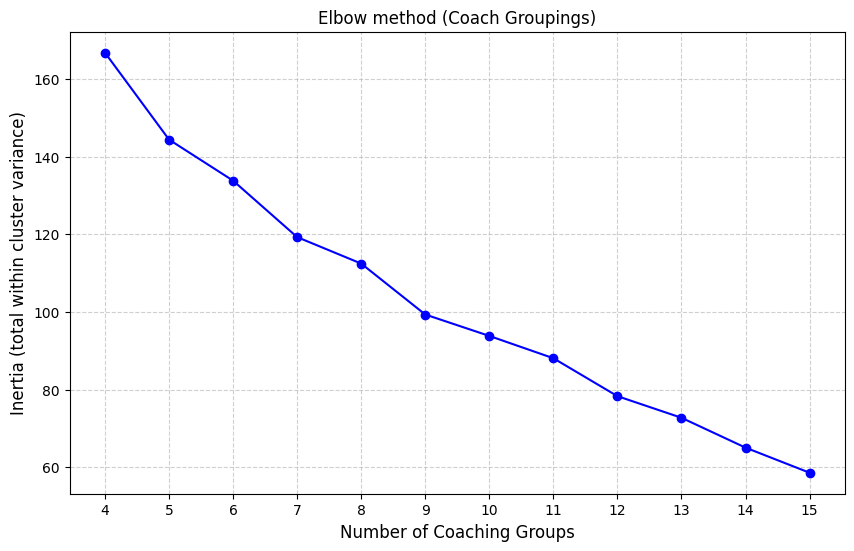

In [149]:
X_coaches = coach_profiles.copy()

X_coaches.columns = X_coaches.columns.astype(str)
scaler_elbow = StandardScaler()
X_coaches_scaled = scaler_elbow.fit_transform(X_coaches)

inertia = []
k_range = range(4, 16)

for k in k_range:
  kmeans = KMeans(n_clusters = k, random_state = 42, n_init = 10)
  kmeans.fit(X_coaches_scaled)
  inertia.append(kmeans.inertia_)

plt.figure(figsize = (10, 6))
plt.plot(k_range, inertia, marker = "o", linestyle = "-", color = "blue")
plt.xlabel("Number of Coaching Groups", fontsize = 12)
plt.ylabel("Inertia (total within cluster variance)", fontsize = 12)
plt.title("Elbow method (Coach Groupings)")
plt.xticks(k_range)
plt.grid(True, linestyle = "--", alpha = 0.6)
plt.show()

In [150]:
scaler_coaches = StandardScaler()
scaled_profiles = scaler_coaches.fit_transform(coach_profiles)

num_coach_clusters = 9

kmeans_coaches = KMeans(n_clusters = num_coach_clusters, random_state = 42, n_init = 10)
coach_profiles["offensive_philosophy_group"] = kmeans_coaches.fit_predict(scaled_profiles)

for group in range(num_coach_clusters):
  teams_in_group = coach_profiles[coach_profiles["offensive_philosophy_group"] == group].index.tolist()
  print(f"\nGroup {group} Coaching Identity:")
  print(teams_in_group)


Group 0 Coaching Identity:
['GB', 'IND']

Group 1 Coaching Identity:
['CIN', 'DEN']

Group 2 Coaching Identity:
['JAX', 'LA', 'NE', 'PHI']

Group 3 Coaching Identity:
['NYJ', 'TEN']

Group 4 Coaching Identity:
['ARI', 'DET', 'HOU', 'KC', 'LAC', 'SF']

Group 5 Coaching Identity:
['CAR', 'MIA']

Group 6 Coaching Identity:
['BAL', 'BUF', 'SEA']

Group 7 Coaching Identity:
['CLE', 'LV', 'MIN', 'NO', 'TB']

Group 8 Coaching Identity:
['ATL', 'CHI', 'DAL', 'NYG', 'PIT', 'WAS']


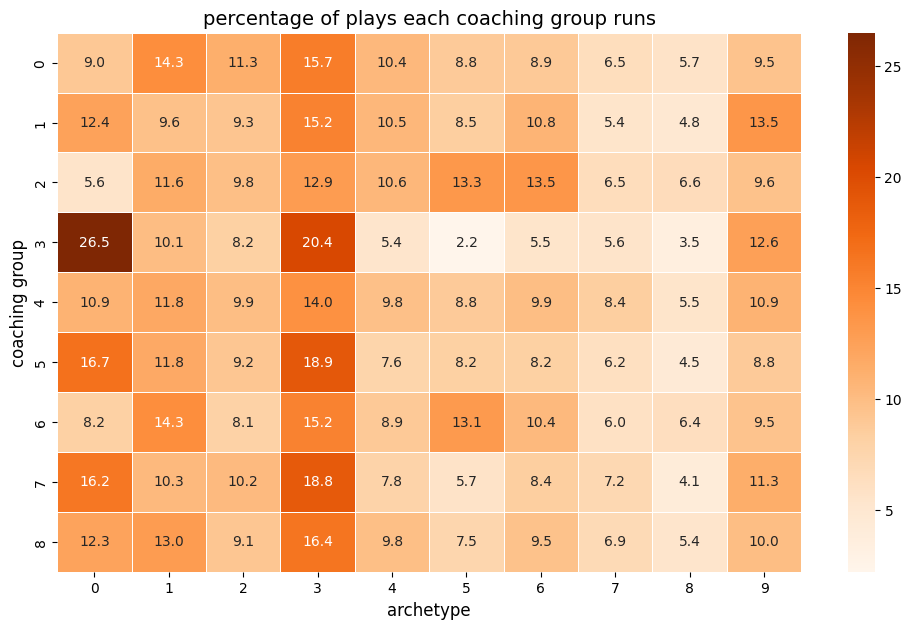

In [151]:
master_df = master_df.merge(
    coach_profiles[["offensive_philosophy_group"]],
    left_on = "posteam",
    right_index = True,
    how = "left"
)

group_behaviour = pd.crosstab(
    master_df["offensive_philosophy_group"],
    master_df["play_archetype"],
    normalize = "index"
) * 100

plt.figure(figsize=(12, 7))
sns.heatmap(group_behaviour, annot=True, fmt=".1f", cmap="Oranges", linewidths=.5)
plt.title("percentage of plays each coaching group runs", fontsize=14)
plt.xlabel("archetype", fontsize=12)
plt.ylabel("coaching group", fontsize=12)
plt.show()

# Labelling Coaching Groups

"Coaching Group 1" means nothing. We're going to use quantifiable data from our play archetypes along with real-world context to label our groups.

In [152]:
def profile(df, profiles_df):
  grouped = df.groupby("offensive_philosophy_group")

  for group_id, group_df in grouped:
    teams_in_group = group_df["posteam"].unique()
    print(f"coaching group {group_id}")
    print(f"teams: {list(teams_in_group)}")

    pass_pct = (group_df["play_type"] == "pass").mean() * 100
    run_pct = (group_df["play_type"] == "run").mean() * 100
    shotgun_pct = (group_df["shotgun"] == 1).mean() * 100
    no_huddle_pct = (group_df["no_huddle"] == 1).mean() * 100

    print(f"Play Call Mix:        {pass_pct:.1f}% Pass / {run_pct:.1f}% Run")
    print(f"Shotgun Rate:         {shotgun_pct:.1f}%")
    print(f"No-Huddle Rate:       {no_huddle_pct:.1f}%")

    group_allocations = profiles_df[profiles_df["offensive_philosophy_group"] == group_id].iloc[:, :-1].mean()
    playbook_spread = group_allocations.std()
    print(f"Playbook Variance:    {playbook_spread:.2f}")

    print("-" * 50)

profile(master_df, coach_profiles)

coaching group 0
teams: ['GB', 'IND']
Play Call Mix:        54.7% Pass / 45.3% Run
Shotgun Rate:         67.7%
No-Huddle Rate:       7.0%
Playbook Variance:    3.12
--------------------------------------------------
coaching group 1
teams: ['CIN', 'DEN']
Play Call Mix:        61.8% Pass / 38.2% Run
Shotgun Rate:         73.8%
No-Huddle Rate:       7.9%
Playbook Variance:    3.29
--------------------------------------------------
coaching group 2
teams: ['JAX', 'PHI', 'LA', 'NE']
Play Call Mix:        55.6% Pass / 44.4% Run
Shotgun Rate:         58.4%
No-Huddle Rate:       8.7%
Playbook Variance:    2.96
--------------------------------------------------
coaching group 3
teams: ['NYJ', 'TEN']
Play Call Mix:        58.8% Pass / 41.2% Run
Shotgun Rate:         73.3%
No-Huddle Rate:       10.0%
Playbook Variance:    7.86
--------------------------------------------------
coaching group 4
teams: ['ARI', 'DET', 'HOU', 'KC', 'LAC', 'SF']
Play Call Mix:        59.4% Pass / 40.6% Run
Shotgun Ra

In [153]:
group_labels = {
    0: "RPO Driven Pistol & Ground Hybrid",
    1: "High-Volume Shotgun Spread & Spacing",
    2: "Under-Center West Coast Base",
    3: "High-Variance Reactionary Shotgun Spread",
    4: "Structure Rhythm & Script-Disiplined Systems",
    5: "Horizontal Stretch & Perimeter Speed Attack",
    6: "Dual-Threat Power & Heavy-Personnel Base",
    7: "Mid-Zone Spread & Aerial Spacing",
    8: "Hybrid Spread & Iso Heavy Attack"
}

In [154]:
viz_df = pd.merge(
    season_stats,
    coach_profiles,
    left_on = "team",
    right_on = "posteam",
    how = "left"
)

# Final Visualization

To sum up our findings, we're going to plot teams versus their wins from the 2025 season, and group them with the teams that share their offensive tendencies the most, so that we can answer our original question of whether teams who have similar offensive play-calling have similar win rates.

/tmp/ipykernel_9864/358700559.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


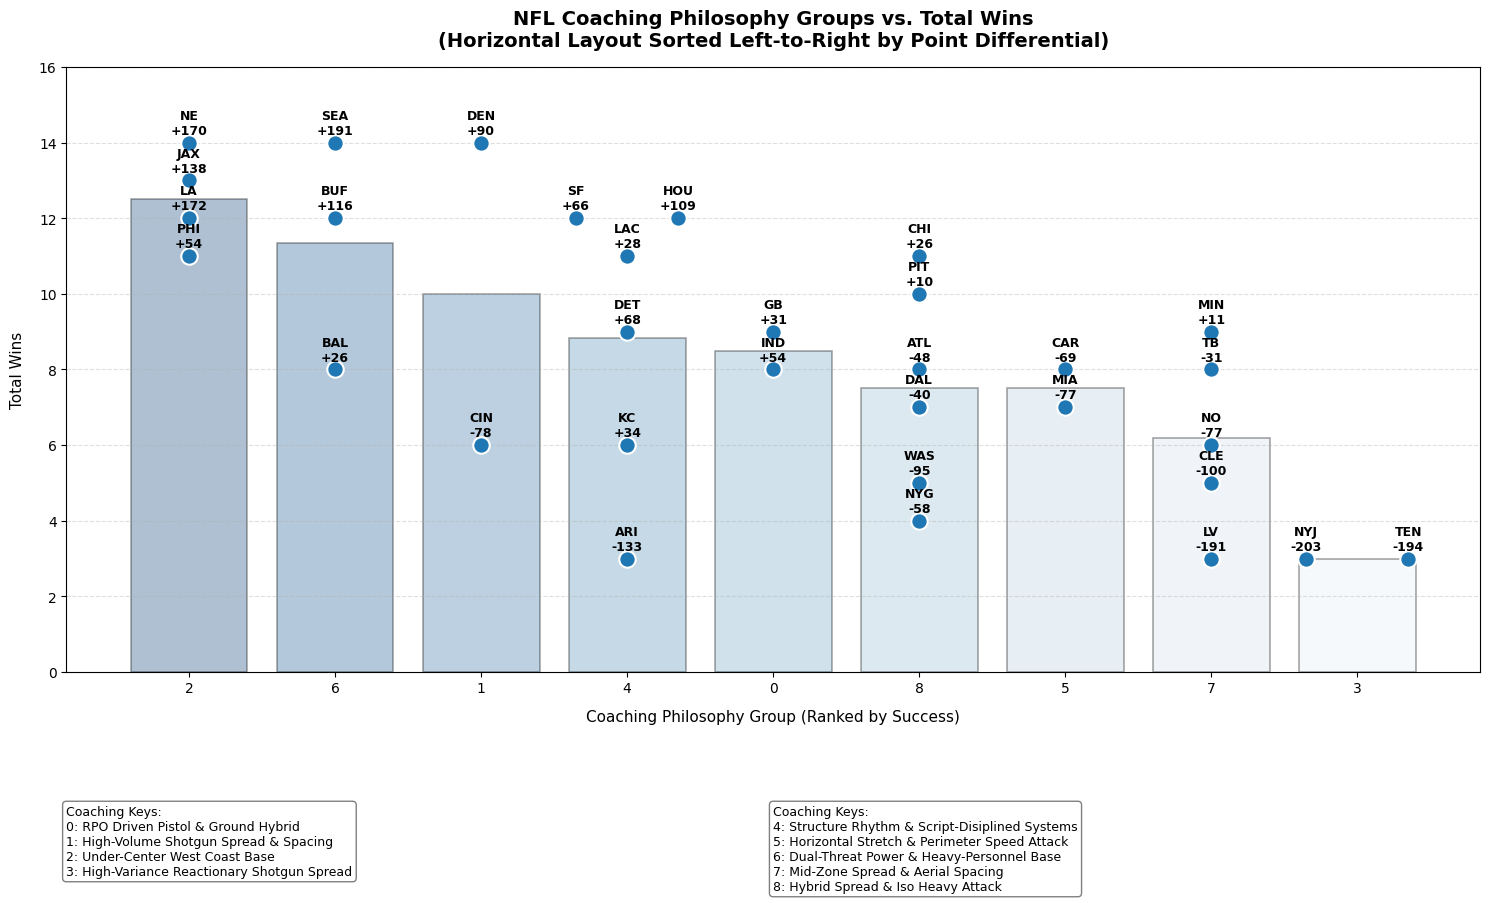

In [157]:
plt.figure(figsize = (15, 12), dpi = 100)

group_order_idx_sorted = group_order.sort_values()

group_order = (
    viz_df.groupby("offensive_philosophy_group")[["wins", "differential"]]
    .mean().sort_values(by = ["wins", "differential"], ascending = False).index
)

sns.barplot(
    data = viz_df,
    x = "offensive_philosophy_group",
    y = "wins",
    order = group_order,
    palette = "Blues_r",
    alpha = 0.35,
    errorbar = None,
    edgecolor = "black",
    linewidth = 1.2,
    zorder = 1
)

plt.grid(axis = "y", linestyle = "--", alpha = 0.4, zorder = 0)

for i, group in enumerate(group_order):
  group_teams = viz_df[viz_df["offensive_philosophy_group"] == group]
  unique_win_values = sorted(group_teams["wins"].unique())

  for w in unique_win_values:
    tied_df = group_teams[group_teams["wins"] == w].sort_values(by = "differential", ascending = True)
    teams = tied_df["team"].tolist()
    diffs = tied_df["differential"].tolist()
    num_teams = len(teams)

    x_offsets = np.linspace(-0.35, 0.35, num_teams) if num_teams > 1 else [0]

    for idx, team in enumerate(teams):
      current_x = i + x_offsets[idx]

      plt.scatter(current_x, w, color="#1f77b4", s=140, edgecolors="white", linewidths=1.5, zorder=3)

      label_text = f"{team}\n{diffs[idx]:+g}"

      plt.text(
                x=current_x,
                y= w + 0.15,
                s=label_text,
                fontsize=9,
                fontweight="bold",
                ha="center",
                va="bottom",
                zorder=4
            )

plt.title("NFL Coaching Philosophy Groups vs. Total Wins\n(Horizontal Layout Sorted Left-to-Right by Point Differential)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Coaching Philosophy Group (Ranked by Success)", fontsize=11, labelpad=10)
plt.ylabel("Total Wins", fontsize=11, labelpad=10)
plt.ylim(0, viz_df["wins"].max() + 2)

col1_groups = group_order_idx_sorted[:4]
col2_groups = group_order_idx_sorted[4:]

col1_text = "Coaching Keys: \n" + "\n".join([f"{g}: {group_labels[g]}" for g in col1_groups])
col2_text = "Coaching Keys: \n" + "\n".join([f"{g}: {group_labels[g]}" for g in col2_groups])

plt.text(0.0, -0.22, col1_text, transform=plt.gca().transAxes, fontsize=9, va='top', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))
plt.text(0.5, -0.22, col2_text, transform=plt.gca().transAxes, fontsize=9, va='top', ha='left', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))


plt.tight_layout(rect = [0, 0.18, 1, 1])
plt.show()


# Conclusion

Clear trends emerge from the graph, mainly that the winners are seperated from losers.

1. NE, JAX, LA and PHI seperate themselves from the rest with their West Coast foundation. It is clear to everyone else that their strategy wins football games, and if possible, it would be very beneficial to replicate it.

2. "Down Years" are apparent. Teams like BAL, CIN and KC find themselves in groups that seem like they should win football games, but appear to be outliers without context. Using our real-world knowledge, we know that both these teams had major injuries which inhibited them from reaching their full potential in the 2025 season. Lucky for them, these losses seem to be avoidable, since they appear to have a solid offensive philisophy in place, just lacking the injury luck to execute properly.

3. NYJ and TEN stand alone, and not in a good way. These teams sit firmly at the bottom of the league and in their own category of offense together. Both these teams are continuing to rebuild their rosters and trasition into a new era, so this is to be expected. However, if they want to win in the near future, it's clear they need consistency and vision if they want their offense to succeed.

It can be noted that there is one major outlier (ignoring the injury-riddled teams mentioned above); the Arizona Cardinals. I believe this indicates that the blueprit behind the Cardinal's offense is sound and can be built around, but that the roster limits what the team can do.

To Finish, I believe we can answer our original question. It can be concluded teams with similar offensive play-calling do win at similar rates, despite roster differences. My next step will be to determine whether this trend is apparent across multiple seasons, and how offensive philisophy groupings respective win rates vary across time.

In [158]:
joblib.dump(final_kmeans, "nfl_offensive_kmeans_model_v2.joblib")
joblib.dump(scaler_coaches, "scaler_coaches_v2.joblib")
joblib.dump(kmeans_coaches, "kmeans_coaches_philisophy_v2.joblib")

['kmeans_coaches_philisophy_v2.joblib']